Here a look at this interactive convolution visualizer [Convolution Visualizer](https://ezyang.github.io/convolution-visualizer/)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

import math
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
%matplotlib inline

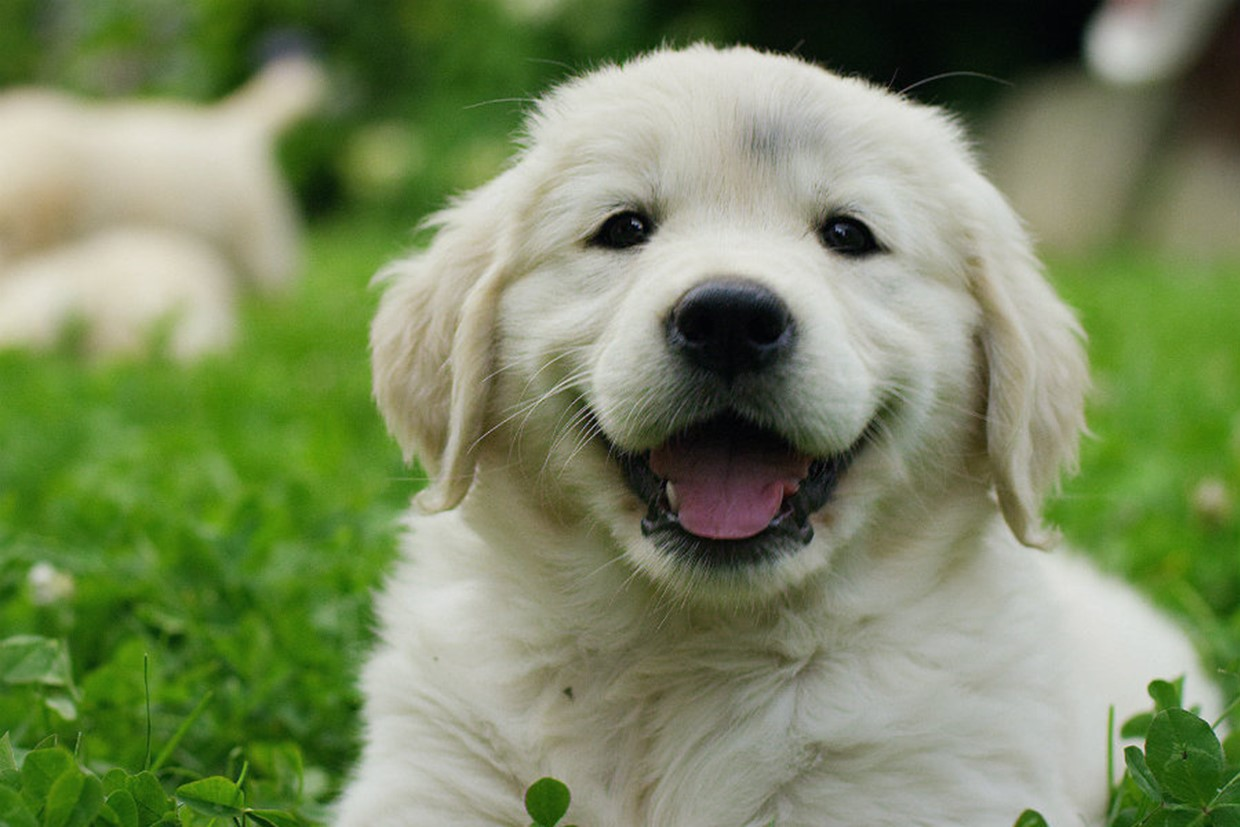

In [2]:
test_img1 = Image.open("./data/puppy.jpg").convert("RGB")
test_img1

In [3]:
# Pytorch transform
# Takes PIL iamge and converts it to a tensor

transform = T.ToTensor()

resize = T.Resize(512)
test_img1 = transform(resize(test_img1))
print("Image shape: ", test_img1.shape)

Image shape:  torch.Size([3, 512, 767])


In [8]:
# create a filter that will extract edges in the x direction
gx = torch.FloatTensor([[-1, 0, 1],
                        [-2, 0, 2], 
                        [-1, 0, 1]])
print(gx.shape, gx)
gx = gx.unsqueeze(0)
print(gx.shape, gx)

torch.Size([3, 3]) tensor([[-1.,  0.,  1.],
        [-2.,  0.,  2.],
        [-1.,  0.,  1.]])
torch.Size([1, 3, 3]) tensor([[[-1.,  0.,  1.],
         [-2.,  0.,  2.],
         [-1.,  0.,  1.]]])


In [9]:
gx = torch.repeat_interleave(gx, 3, 0)
print(gx.shape, gx)
gx = gx.unsqueeze(0)
print(gx.shape, gx)

torch.Size([3, 3, 3]) tensor([[[-1.,  0.,  1.],
         [-2.,  0.,  2.],
         [-1.,  0.,  1.]],

        [[-1.,  0.,  1.],
         [-2.,  0.,  2.],
         [-1.,  0.,  1.]],

        [[-1.,  0.,  1.],
         [-2.,  0.,  2.],
         [-1.,  0.,  1.]]])
torch.Size([1, 3, 3, 3]) tensor([[[[-1.,  0.,  1.],
          [-2.,  0.,  2.],
          [-1.,  0.,  1.]],

         [[-1.,  0.,  1.],
          [-2.,  0.,  2.],
          [-1.,  0.,  1.]],

         [[-1.,  0.,  1.],
          [-2.,  0.,  2.],
          [-1.,  0.,  1.]]]])


In [10]:
gy = torch.FloatTensor([[1, 2, 1],
                        [0, 0, 0], 
                        [-1, -2, -1]]).unsqueeze(0)
gy = torch.repeat_interleave(gy, 3, 0).unsqueeze(0)
print(gy.shape, gy)

torch.Size([1, 3, 3, 3]) tensor([[[[ 1.,  2.,  1.],
          [ 0.,  0.,  0.],
          [-1., -2., -1.]],

         [[ 1.,  2.,  1.],
          [ 0.,  0.,  0.],
          [-1., -2., -1.]],

         [[ 1.,  2.,  1.],
          [ 0.,  0.,  0.],
          [-1., -2., -1.]]]])


Feature map shape:  torch.Size([1, 1, 510, 765])


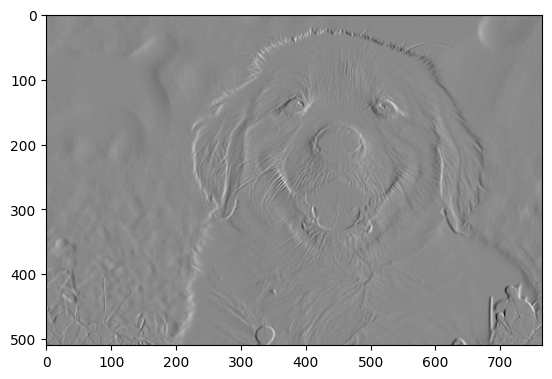

In [11]:
conv_out_1 = F.conv2d(test_img1.unsqueeze(0), gx, bias=None, stride=1)
print("Feature map shape: ", conv_out_1.shape)
plt.imshow(torch.squeeze(conv_out_1), cmap='gray')

Feature map shape:  torch.Size([1, 1, 510, 765])


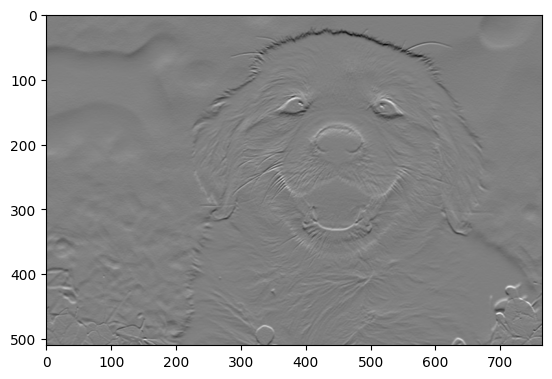

In [12]:
conv_out_2 = F.conv2d(test_img1.unsqueeze(0), gy, bias=None, stride=1)
print("Feature map shape: ", conv_out_2.shape)
plt.imshow(torch.squeeze(conv_out_2), cmap='gray')

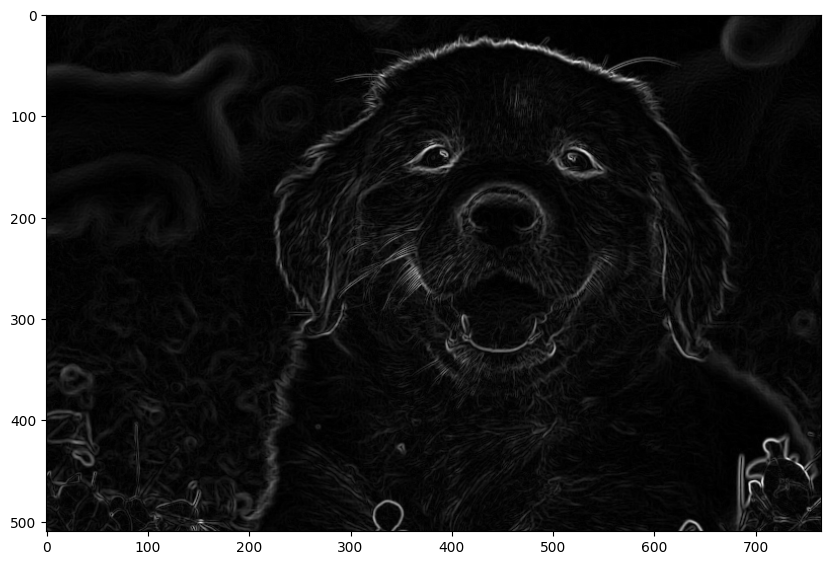

In [14]:
conv_out = (conv_out_1**2 + conv_out_2**2).sqrt()
plt.figure(figsize=(10, 10))
plt.imshow(conv_out.squeeze(), cmap='gray')

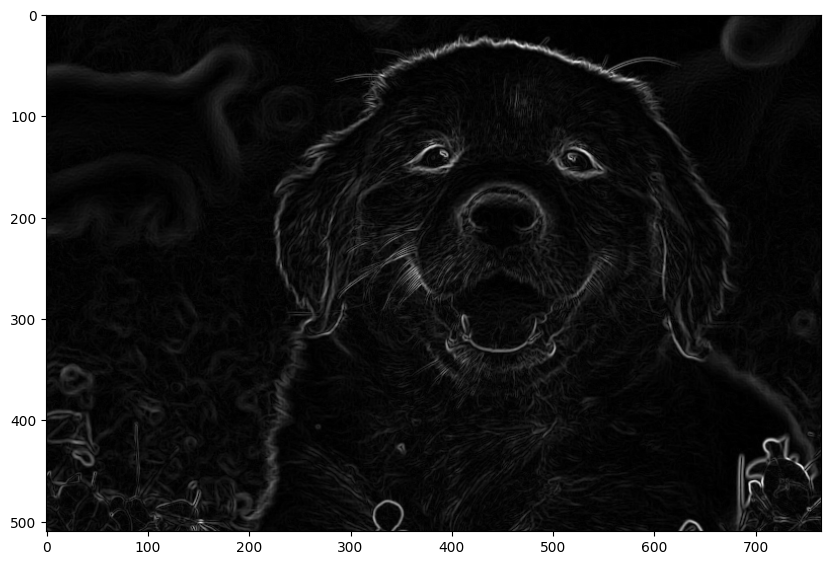

In [15]:
# concatenate both kernels
g_xy = torch.cat((gx, gy), dim=0)

# perform the convolutions of both kernels in the same step
conv_out_3 = F.conv2d(test_img1.unsqueeze(0), g_xy, bias=None, stride=1)

# easy find the magnitude
conv_out_mag = conv_out_3.pow(2).sum(dim=1).sqrt()

plt.figure(figsize=(10, 10))
plt.imshow(conv_out_mag.squeeze(), cmap='gray')

In [17]:
# kernel_size - the width and height of the filter
# stride - how many pixels to move the filter at each step
# padding - how many pixels to add around the image
# bias - same as a linear layer, 1 bias term per output channel

conv_kernel = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=(3, 3), stride=1, padding=1, bias=False)

optimizer = optim.SGD(conv_kernel.parameters(), lr=1e-2)

In [19]:
conv_kernel.weight.shape

torch.Size([1, 3, 3, 3])

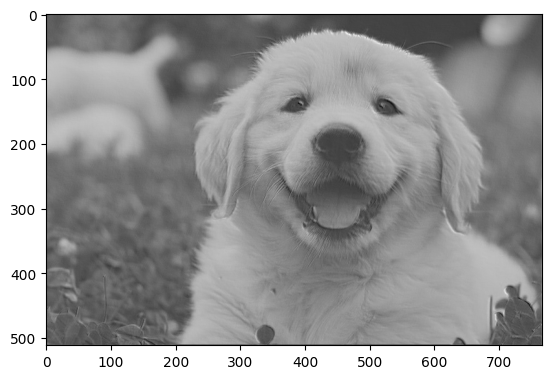

In [20]:
with torch.no_grad():
    img_out = conv_kernel(test_img1.unsqueeze(0))
    plt.imshow(img_out[0, 0], cmap='gray')

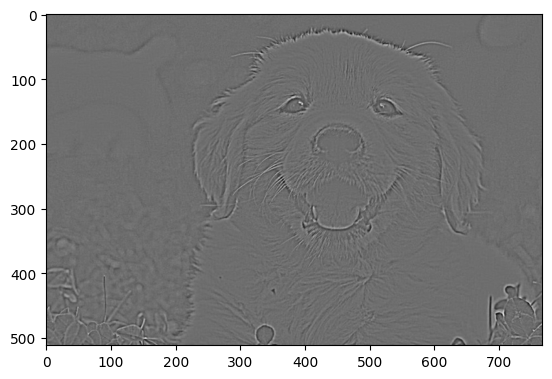

In [21]:
blur = T.GaussianBlur(7, 4)

# Blur the image and substract this forom the original
# Blurring will leave only the high frequemcy on the image
# By subsctracting them from the original, we should get only the high frequency components

target = test_img1.unsqueeze(0) - blur(test_img1).unsqueeze(0)
plt.imshow(torch.squeeze(target[0, 0]), cmap='gray')

In [22]:
logger = []

for _ in trange(2000):
    imgs_out = conv_kernel(test_img1.unsqueeze(0))

    loss = (target - imgs_out).pow(2).mean()
    logger.append(loss.item())
    conv_kernel.zero_grad()
    loss.backward()
    optimizer.step()

100%|██████████| 2000/2000 [00:20<00:00, 97.00it/s] 


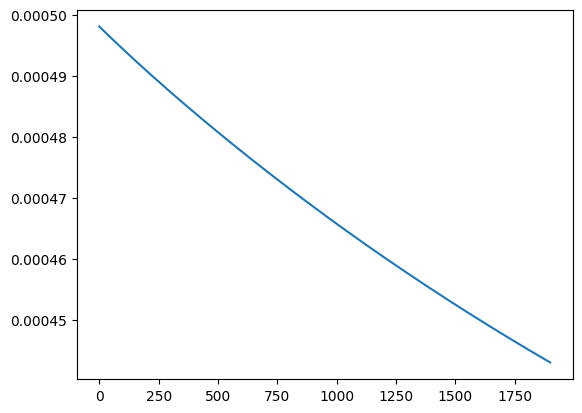

In [27]:
plt.plot(logger[100:])

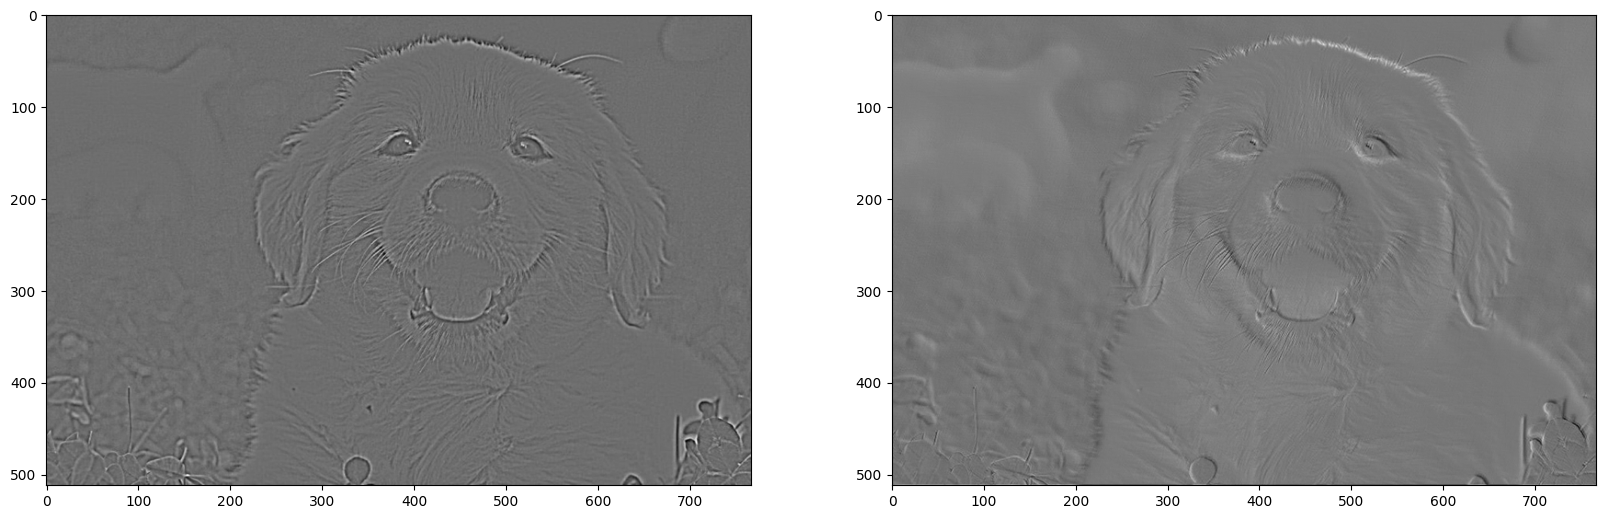

In [28]:
f, (ax1, ax2) = plt.subplots(1, 2, sharex=True, figsize=(20, 10))
ax2.imshow(torch.squeeze(imgs_out[0, 0].detach()), cmap='gray')
ax1.imshow(torch.squeeze(target[0, 0]), cmap='gray')

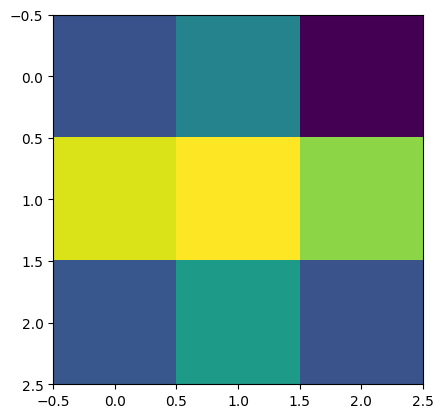

In [29]:
plt.imshow(conv_kernel.weight.data[0, 1].numpy())